In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

from sklearn.metrics import accuracy_score, classification_report

In [2]:
# import the dataset.
data = load_iris()

In [3]:
# load the dataset. 
X = data.data[ : , 0:2]
y = data.target

In [4]:
# train-test-split. 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

In [5]:
# apply the model. 
clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [6]:
y_pred = clf.predict(X_test)

In [7]:
# accuracy score. 
print('Accuarcy : ', accuracy_score(y_test, y_pred))

Accuarcy :  0.7666666666666667


In [8]:
# classification_report. 
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.57      0.50      0.53         8
           2       0.60      0.75      0.67         8

    accuracy                           0.77        30
   macro avg       0.72      0.73      0.72        30
weighted avg       0.78      0.77      0.77        30



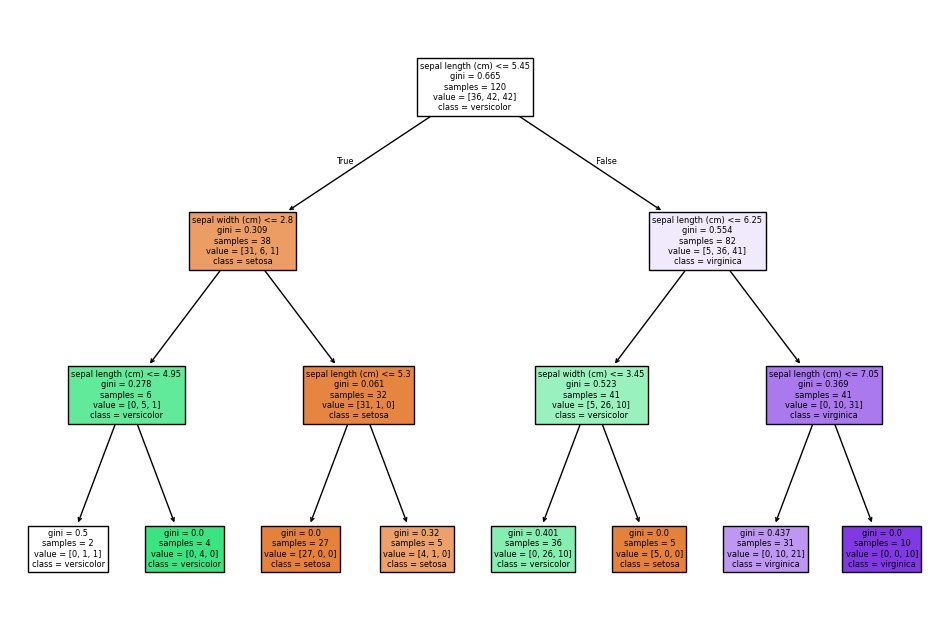

In [9]:
# Plot the decision tree
plt.figure(figsize=(12, 8))
plot_tree(clf, filled=True, feature_names=data.feature_names[:2], class_names=data.target_names)
plt.show()

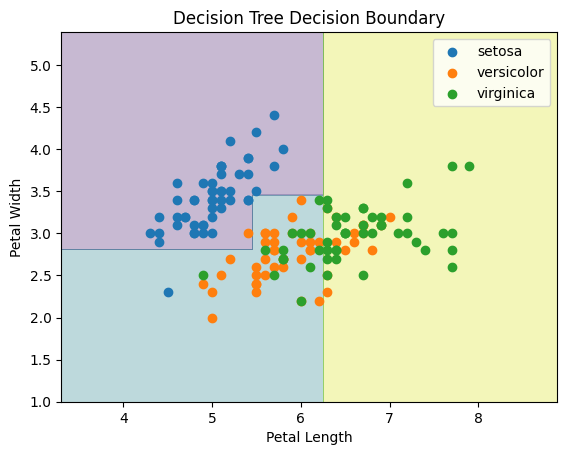

In [10]:
# Define grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.01),
    np.arange(y_min, y_max, 0.01)
)

# predict for every Grid point. 
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


plt.figure()

# Plot decision regions
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot actual data points
for i in range(3):
    plt.scatter(X[y == i, 0], X[y == i, 1], label=data.target_names[i])

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Decision Tree Decision Boundary")
plt.legend()
plt.show()